In [1]:
from src import *

In [2]:
width = 8.5 / 2.54 #inches

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb, physics, mathpazo, microtype}'

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))


spade_params = {
    'marker': 'o',
    'edgecolors': '#9467bd',
    'facecolors': 'none',
    's': 3,
    'linewidths': 0.5
}


di_params = {
    'marker': '+',
    'facecolor': '#2ca02c',

    's': 6,
    'linewidths': 0.5
}

c_red = '#d62728'

In [3]:
# STOP HERE
raise

RuntimeError: No active exception to reraise

# ideal

In [ ]:
# spade_mean = {3: [], 5: []}
# spade_var = {3: [], 5: []}
# spade_f = {3: [], 5: []}


# di_mean = {3: [], 5: []}
# di_var = {3: [], 5: []}
# di_f = {3: [], 5: []}


# for a in (3, 5):
#     for f_ in np.linspace(0.1, 0.4, 61):
#         f = np.round(f_, 5)
#         spade_c = LoadEstimates(f'data/ideal/spade_{a}px_f{f}_d0.npz')
#         di_c = LoadEstimates(f'data/ideal/di_{a}px_f{f}_d0.npz')

#         spade_f[a].append(spade_c.metadata.ground_truth)
#         spade_mean[a].append(spade_c.estimates.mean())
#         spade_var[a].append(spade_c.estimates.var(ddof=1) * spade_c.photons)

#         di_f[a].append(di_c.metadata.ground_truth)
#         di_mean[a].append(di_c.estimates.mean())
#         di_var[a].append(di_c.estimates.var(ddof=1) * di_c.photons)

In [4]:
spade_mean = {a: np.load(f'result/expt/ideal/spade_{a}px.npz')['mean'] for a in (3, 5)}
spade_var = {a: np.load(f'result/expt/ideal/spade_{a}px.npz')['var'] for a in (3, 5)}
spade_f = {a: np.linspace(0.1, 0.4, 61) for a in (3, 5)}


di_mean = {a: np.load(f'result/expt/ideal/di_{a}px.npz')['mean'] for a in (3, 5)}
di_var = {a: np.load(f'result/expt/ideal/di_{a}px.npz')['var'] for a in (3, 5)}
di_f = {a: np.linspace(0.1, 0.4, 61) for a in (3, 5)}

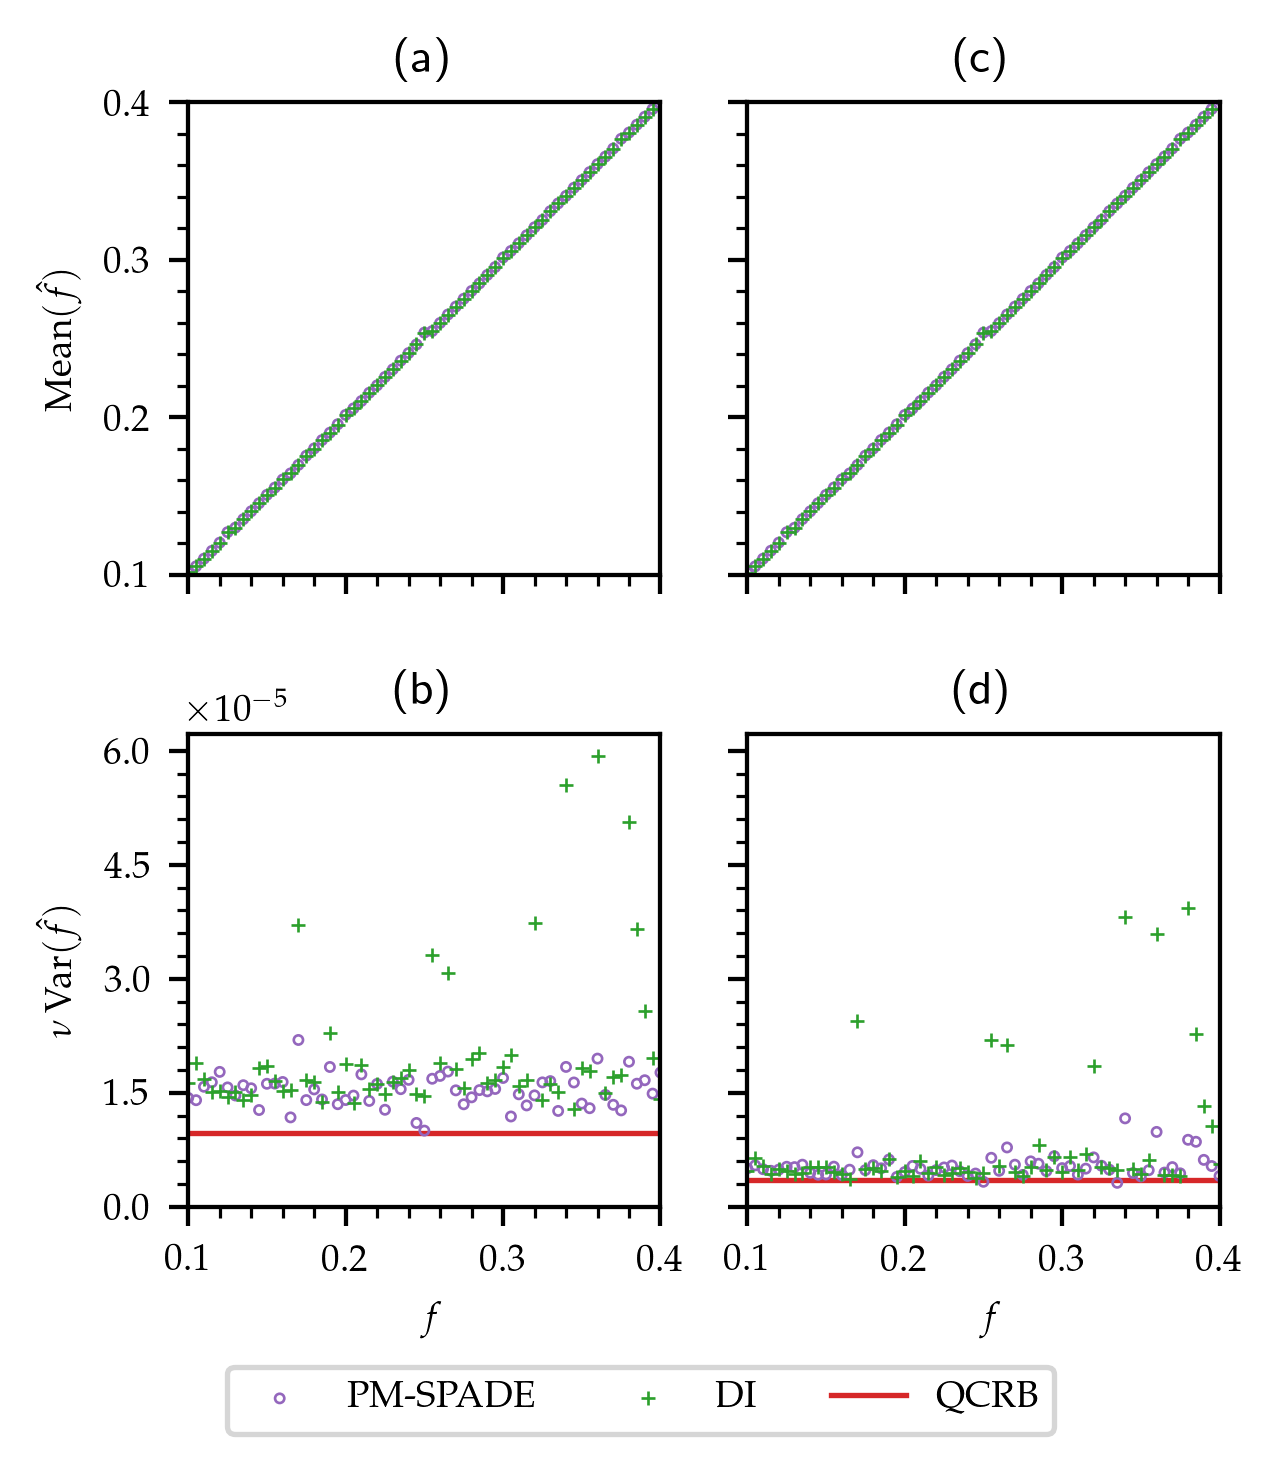

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(width, width*1.1), sharex=True, sharey='row')

axs = {
    3: (ax[0, 0], ax[1, 0]),
    5: (ax[0, 1], ax[1, 1])
}


for a in (3, 5):
    line1 = axs[a][0].scatter(spade_f[a], spade_mean[a], **spade_params)
    line2 = axs[a][0].scatter(di_f[a], di_mean[a], **di_params)
    # axs[a][0].plot(spade_f[a], spade_mean[a], linewidth=1, linestyle='--')
    # axs[a][0].plot(di_f[a], di_mean[a], linewidth=1, linestyle='-.')

    x_axis = np.linspace(0.1, 0.4, 61)
    fi = DI.ApproxCFI(4/np.pi*DMD.A(a))
    crb = np.ones(61) / fi
    line3, = axs[a][1].plot(x_axis, crb, c_red, linewidth=1, zorder=1)

    axs[a][1].scatter(spade_f[a], spade_var[a], **spade_params)
    axs[a][1].scatter(di_f[a], di_var[a], **di_params)

    # axs[a][0].set_title(rf'${np.round(DMD.A(a)/103, 2)}\sigma$')
    # axs[a][1].set_title(rf'${np.round(DMD.A(a)/103, 2)}\sigma$')


for i, ax_ in enumerate(np.ravel(ax)):
    ax_.set_box_aspect(1)
    ax_.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax_.yaxis.set_minor_locator(AutoMinorLocator(5))
    # ax_.text(-0.15, 1.2, 
    #          [r'$\mathbf{\textsf{(' + _ + r')}}$' for _ in ('a', 'b', 'c', 'd')][i], 
    #          fontsize=9, transform=ax_.transAxes, va='top', ha='left')

ax[0, 0].set_title(r'$\mathbf{\textsf{(a)}}$')
ax[1, 0].set_title(r'$\mathbf{\textsf{(b)}}$')
ax[0, 1].set_title(r'$\mathbf{\textsf{(c)}}$')
ax[1, 1].set_title(r'$\mathbf{\textsf{(d)}}$')


ax[0, 0].set_xlim(0.1, 0.4)
ax[0, 0].set_ylim(0.1, 0.4)
ax[0, 0].set_xticks(np.linspace(0.1, 0.4, 4))
ax[0, 0].set_yticks(np.linspace(0.1, 0.4, 4))

ax[0, 0].set_ylabel(r'$\operatorname{Mean}(\hat f)$')
ax[1, 0].set_ylabel(r'$\nu\operatorname{Var}(\hat f)$')

ax[1, 0].set_xlabel(r'$f$')
ax[1, 1].set_xlabel(r'$f$')
ax[1, 0].set_yticks(np.linspace(0, 6, 5) * 1e-5)
ax[1, 0].yaxis.set_major_formatter(formatter)


fig.legend([line1, line2, line3], ['PM-SPADE', 'DI', 'QCRB'], ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('ideal.pdf')
plt.show()

In [ ]:
# STOP HERE
raise

RuntimeError: No active exception to reraise

# noisy

In [ ]:
# spade_mean, spade_var, spade_b = [], [], []
# di_mean, di_var, di_b = [], [], []
# for d in np.arange(0, 101, 2):
#     spade_c = LoadEstimates(rf'data/noisy/spade_5px_f0.2_d{d}.npz')
#     di_c = LoadEstimates(rf'data/noisy/di_5px_f0.2_d{d}.npz')

#     spade_mean.append(spade_c.estimates.mean())
#     spade_var.append(spade_c.estimates.var(ddof=1) * spade_c.photons)
#     spade_b.append(spade_c.background / spade_c.photons)

#     di_mean.append(di_c.estimates.mean())
#     di_var.append(di_c.estimates.var(ddof=1) * di_c.photons)
#     di_b.append(di_c.background / di_c.photons)

In [6]:
spade_mean, spade_var, spade_b = [np.load('result/expt/noisy/spade_5px.npz')[ff] for ff in ('mean', 'var', 'b')]
di_mean, di_var, di_b = [np.load('result/expt/noisy/di_5px.npz')[ff] for ff in ('mean', 'var', 'b')]

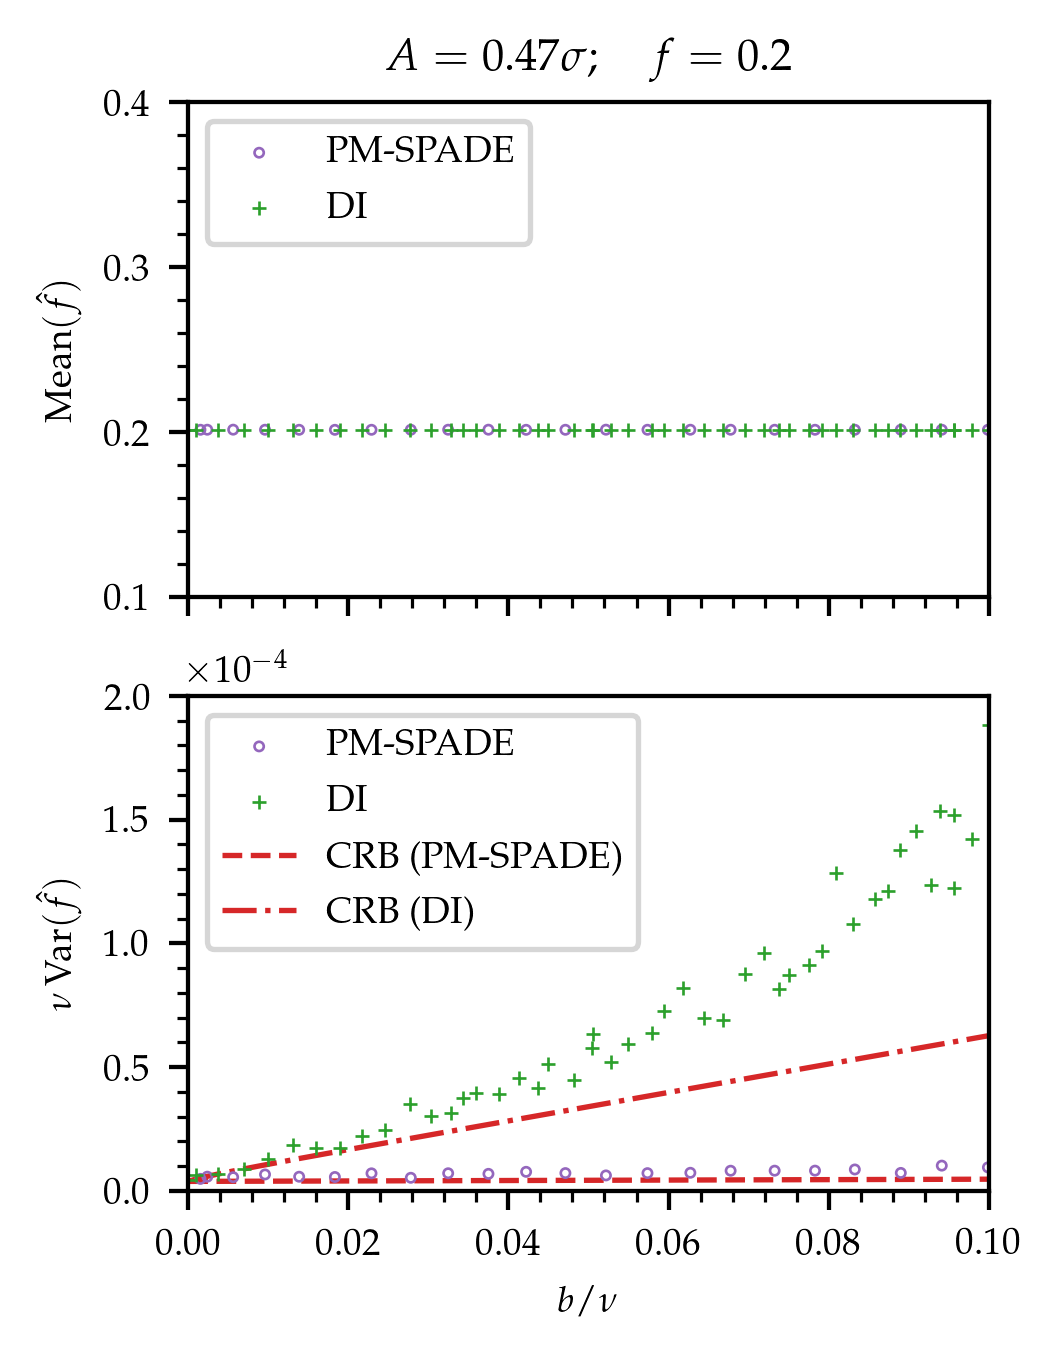

In [7]:
b_axis = np.linspace(1e-10, 0.2, 1000)
spade_crb = 1/SPADE.CFI(b_axis, (4/pi) * DMD.A(5), 0.2)
di_crb = 1/DI.CFI(b_axis, (4/pi) * DMD.A(5), 0.2)

fig, ax = plt.subplots(2, 1, figsize=(width, width*1.1), sharex=True)

ax[0].scatter(spade_b, spade_mean, **spade_params, label='PM-SPADE')
ax[0].scatter(di_b, di_mean, **di_params, label='DI')
ax[0].set_ylim(0.1, 0.4)

ax[1].scatter(spade_b, spade_var, **spade_params, label='PM-SPADE', zorder=2)
ax[1].scatter(di_b, di_var, **di_params, label='DI', zorder=2)

ax[1].plot(b_axis, spade_crb, 
           linestyle='--', linewidth=1, color=c_red, 
           label='CRB (PM-SPADE)', zorder=1)
ax[1].plot(b_axis, di_crb, 
           linestyle='-.', linewidth=1, color=c_red, 
           label='CRB (DI)', zorder=1)

ax[1].yaxis.set_major_formatter(formatter)
ax[1].set_ylim(0, 2e-4)


ax[0].set_ylabel(r'$\operatorname{Mean}(\hat f)$')
ax[1].set_xlabel(r'$b/\nu$')
ax[1].set_ylabel(r'$\nu\operatorname{Var}(\hat f)$')
ax[0].set_title(r'$A = 0.47\sigma;\quad f=0.2$')

for ax_ in ax:
    ax_.set_xlim(0, 0.1)
    ax_.set_box_aspect(0.618)
    ax_.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax_.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax_.legend(loc='upper left')
    

plt.savefig('noisy.pdf')
plt.show()

In [ ]:
#STOP HERE
raise

# simulation: delay/sign

In [8]:
spade_mean = {a: np.load(f'result/sim/delay/sign/spade_{a}px.npz')['mean'] for a in (3, 5)}
spade_var = {a: np.load(f'result/sim/delay/sign/spade_{a}px.npz')['var'] for a in (3, 5)}
spade_f = {a: np.linspace(0.1, 0.4, 61) for a in (3, 5)}


di_mean = {a: np.load(f'result/sim/delay/sign/di_{a}px.npz')['mean'] for a in (3, 5)}
di_var = {a: np.load(f'result/sim/delay/sign/di_{a}px.npz')['var'] for a in (3, 5)}
di_f = {a: np.linspace(0.1, 0.4, 61) for a in (3, 5)}

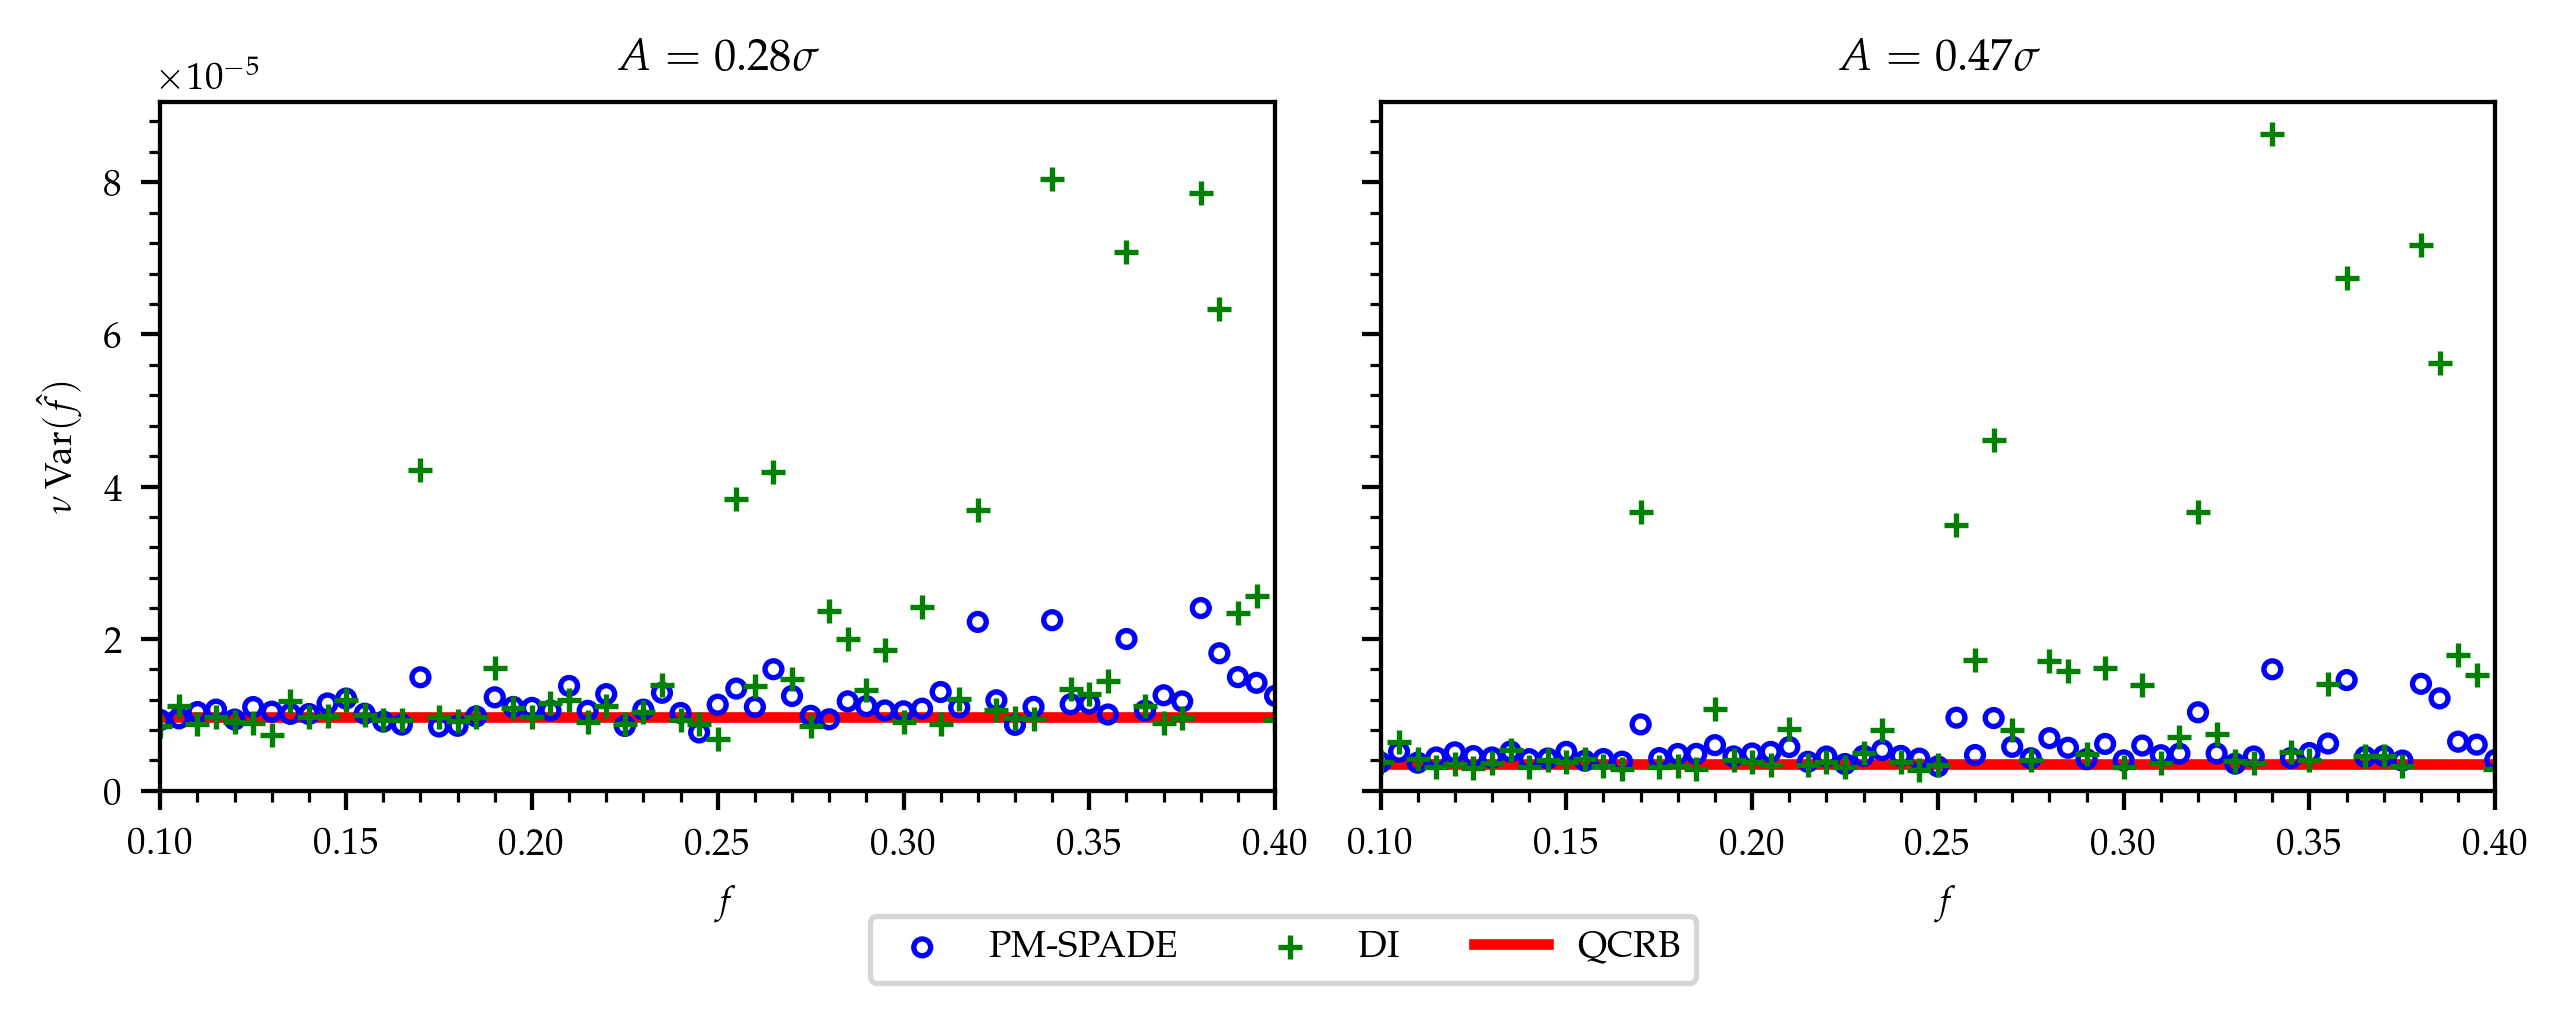

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(width * 2, width * 1.4 / 2), sharey=True)

for ax in (ax1, ax2):
    a = 3 if ax == ax1 else 5

    line1 = ax.scatter(spade_f[a], spade_var[a], marker='o', s=10, edgecolor='b', facecolor='none', zorder=2)
    line2 = ax.scatter(di_f[a], di_var[a], marker='+', s=20, facecolor='g', linewidths=1, zorder=2)

    # print(di_var[a].max())
    # print(di_f[a][np.argmax(di_var[a])])

    # ax.axhline(di_var[a].max(), c='r', linestyle=':', linewidth=1)
    # ax.axvline(di_f[a][np.argmax(di_var[a])], c='r', linestyle=':', linewidth=1)

    x_axis = np.linspace(0.1, 0.4, 61)
    fi = DI.ApproxCFI((4/np.pi)*DMD.A(a))
    crb = np.ones(61) / fi

    line3, = ax.plot(x_axis, crb, 'r', linewidth=2, zorder=1)
    ax.set_title(rf'$A = {np.round(DMD.A(a)/ 103, 2)}\sigma$')

    ax.set_box_aspect(0.618)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.set_xlim(0.1, 0.4)
    ax.yaxis.set_major_formatter(formatter)


ax1.set_ylim(0, None)
ax1.set_yticks(np.linspace(0, 8, 5) * 1e-5)

ax1.set_ylabel(r'$\nu\operatorname{Var}(\hat f)$')
ax1.set_xlabel(r'$f$')
ax2.set_xlabel(r'$f$')

fig.legend([line1, line2, line3], ['PM-SPADE', 'DI', 'QCRB'], ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig('delay(sim).pdf')
plt.show()

In [ ]:
# STOP HERE
raise

RuntimeError: No active exception to reraise

# simulation: delay/sin

In [10]:
spade_mean = {a: np.load(f'result/sim/delay/sin/spade_{a}px.npz')['mean'] for a in (3, 5)}
spade_var = {a: np.load(f'result/sim/delay/sin/spade_{a}px.npz')['var'] for a in (3, 5)}
spade_f = {a: np.linspace(0.1, 0.4, 61) for a in (3, 5)}


di_mean = {a: np.load(f'result/sim/delay/sin/di_{a}px.npz')['mean'] for a in (3, 5)}
di_var = {a: np.load(f'result/sim/delay/sin/di_{a}px.npz')['var'] for a in (3, 5)}
di_f = {a: np.linspace(0.1, 0.4, 61) for a in (3, 5)}

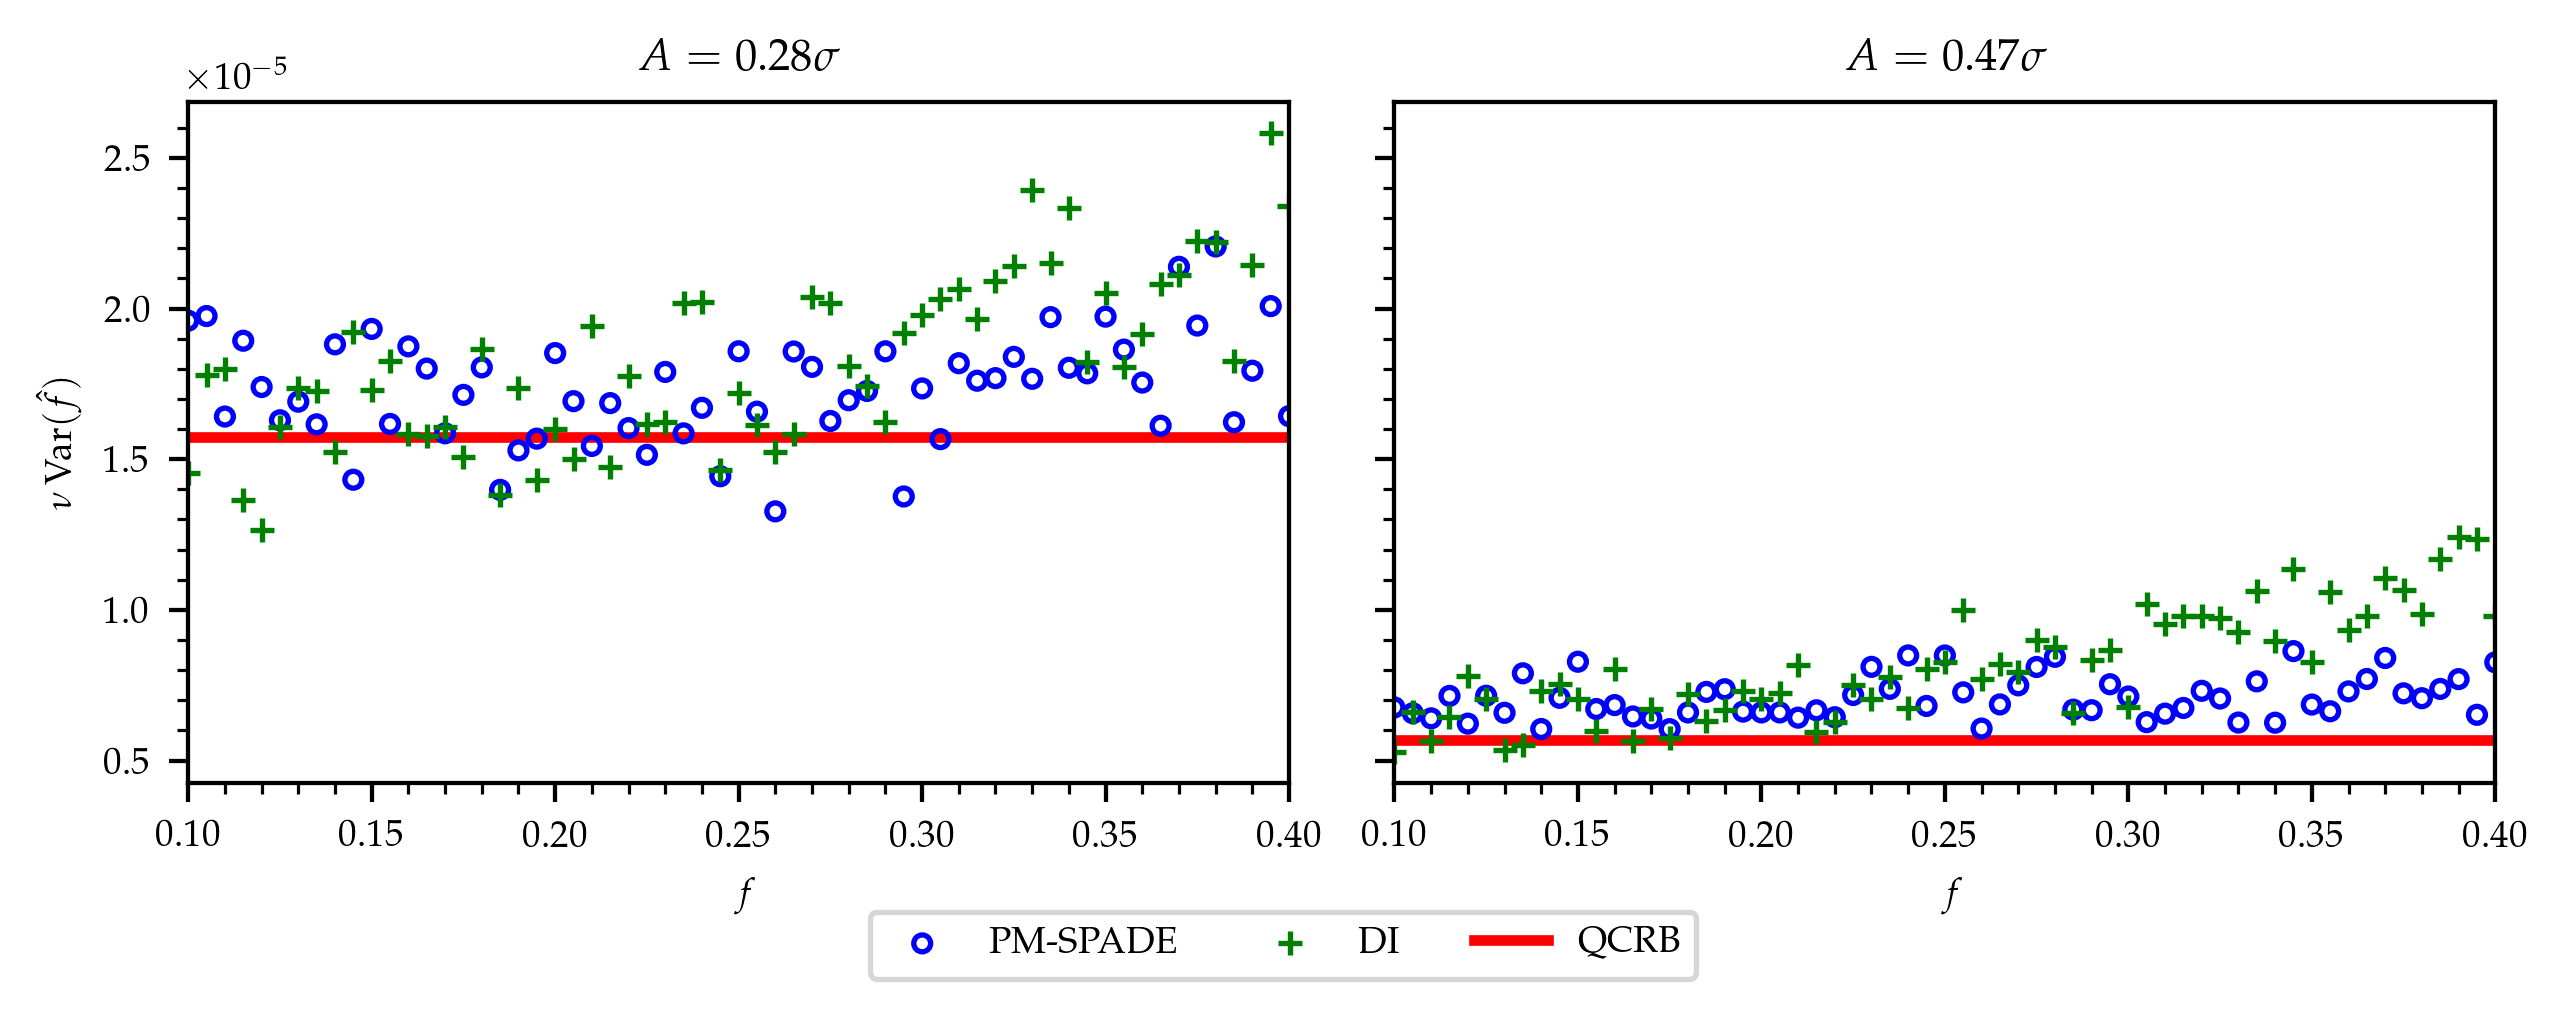

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(width * 2, width * 1.4 / 2), sharey=True)

for ax in (ax1, ax2):
    a = 3 if ax == ax1 else 5

    line1 = ax.scatter(spade_f[a], spade_var[a], marker='o', s=10, edgecolor='b', facecolor='none', zorder=2)
    line2 = ax.scatter(di_f[a], di_var[a], marker='+', s=20, facecolor='g', linewidths=1, zorder=2)

    x_axis = np.linspace(0.1, 0.4, 61)
    fi = DI.ApproxCFI(DMD.A(a))
    crb = np.ones(61) / fi

    line3, = ax.plot(x_axis, crb, 'r', linewidth=2, zorder=1)
    ax.set_title(rf'$A = {np.round(DMD.A(a)/ 103, 2)}\sigma$')

    ax.set_box_aspect(0.618)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.set_xlim(0.1, 0.4)
    ax.yaxis.set_major_formatter(formatter)


ax1.set_ylabel(r'$\nu\operatorname{Var}(\hat f)$')
ax1.set_xlabel(r'$f$')
ax2.set_xlabel(r'$f$')

fig.legend([line1, line2, line3], ['PM-SPADE', 'DI', 'QCRB'], ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig('delay(sim_sin).svg')
plt.show()

In [ ]:
# STOP HERE
raise

# simulation: nodelay

In [12]:
spade_mean = {s: np.load(f'result/sim/nodelay/{s}/spade_3px.npz')['mean'] for s in ('sin', 'sign')}
spade_var = {s: np.load(f'result/sim/nodelay/{s}/spade_3px.npz')['var'] for s in ('sin', 'sign')}
spade_f = np.linspace(0.1, 0.4, 1001)


di_mean = {s: np.load(f'result/sim/nodelay/{s}/di_3px.npz')['mean'] for s in ('sin', 'sign')}
di_var = {s: np.load(f'result/sim/nodelay/{s}/di_3px.npz')['var'] for s in ('sin', 'sign')}
di_f = np.linspace(0.1, 0.4, 1001)

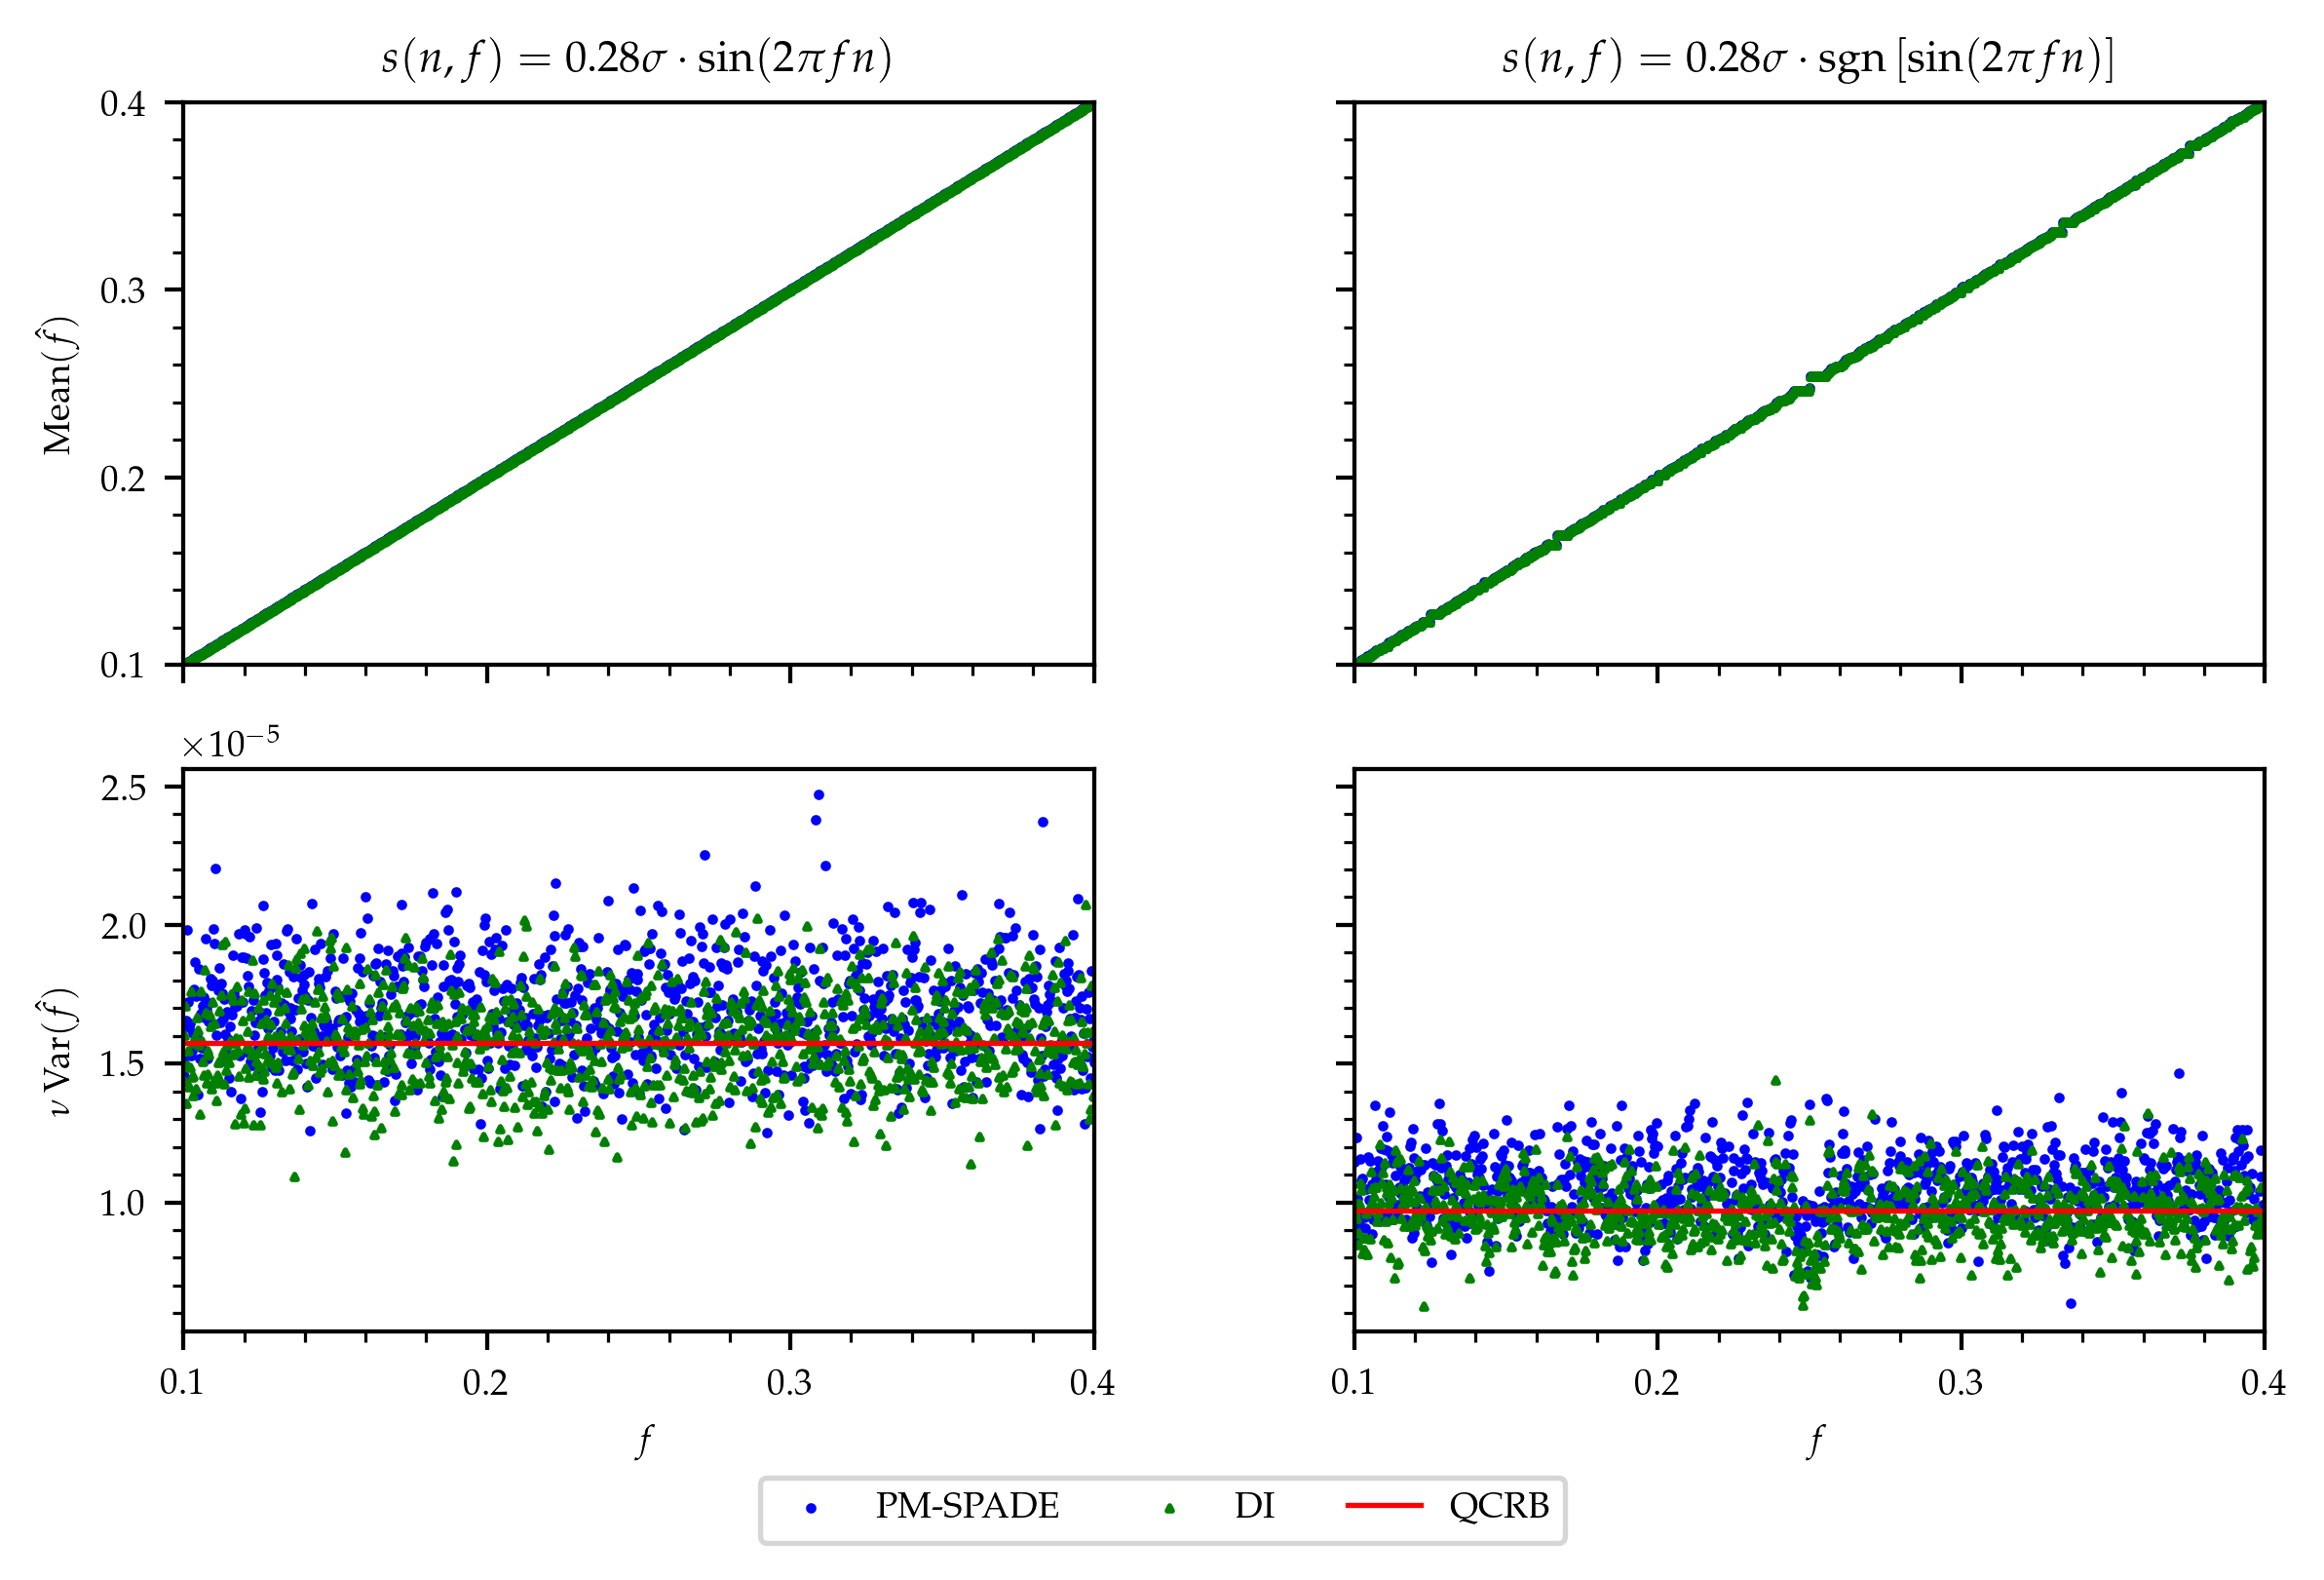

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(width * 2, width * 2 * 0.6), sharex=True, sharey='row')

axs = {
    'sin': (ax[0, 0], ax[1, 0]),
    'sign': (ax[0, 1], ax[1, 1])
}


for a in ('sin', 'sign'):
    line1 = axs[a][0].scatter(spade_f, spade_mean[a], s=1, marker='o', c='b')
    line2 = axs[a][0].scatter(di_f, di_mean[a], s=1, marker='^', c='g')

    x_axis = np.linspace(0.1, 0.4, 61)
    factor = 1 if a == 'sin' else (4 / pi)
    fi = DI.ApproxCFI(factor * DMD.A(3))
    crb = np.ones(61) / fi
    line3, = axs[a][1].plot(x_axis, crb, 'r', linewidth=1, zorder=2)

    axs[a][1].scatter(spade_f, spade_var[a], s=1, marker='o', c='b')
    axs[a][1].scatter(di_f, di_var[a], s=1, marker='^', c='g')


for i, ax_ in enumerate(np.ravel(ax)):
    ax_.set_box_aspect(0.618)
    ax_.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax_.yaxis.set_minor_locator(AutoMinorLocator(5))


ax[0, 0].set_title(r'$s(n, f) = 0.28\sigma\cdot \sin(2\pi f n)$')
ax[0, 1].set_title(r'$s(n, f) = 0.28\sigma\cdot \operatorname{sgn}\qty[\sin(2\pi f n)]$')


ax[0, 0].set_xlim(0.1, 0.4)
ax[0, 0].set_ylim(0.1, 0.4)
ax[0, 0].set_xticks(np.linspace(0.1, 0.4, 4))
ax[0, 0].set_yticks(np.linspace(0.1, 0.4, 4))

ax[0, 0].set_ylabel(r'$\operatorname{Mean}(\hat f)$')
ax[1, 0].set_ylabel(r'$\nu\operatorname{Var}(\hat f)$')

ax[1, 0].set_xlabel(r'$f$')
ax[1, 1].set_xlabel(r'$f$')
ax[1, 0].yaxis.set_major_formatter(formatter)

fig.legend([line1, line2, line3], ['PM-SPADE', 'DI', 'QCRB'], ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('nodelay(sim).pdf')
plt.show()

In [ ]:
# STOP HERE
raise

RuntimeError: No active exception to reraise

# numerical integration

In [14]:
def i(b, sigma=1):
    from scipy.integrate import quad
    b_ = b * sigma
    func = lambda x: (x**2 * np.exp(-x**2)) / (np.sqrt(2*np.pi)*np.exp(-x**2/2) + 2*np.pi*b_)
    return quad(func, -np.inf, np.inf)[0] / sigma**2

x = np.linspace(10e-10, 1, 1000)
y = np.array([i(x_) for x_ in x])

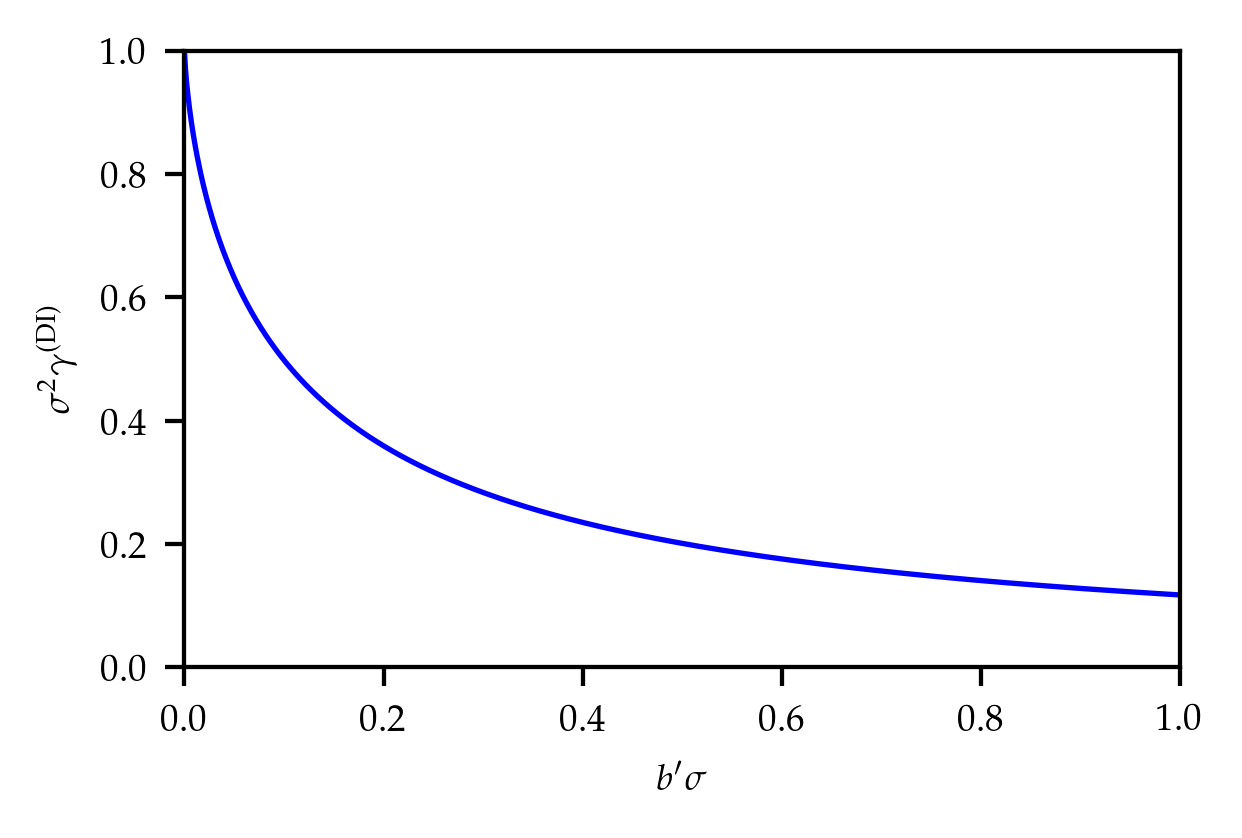

In [15]:
plt.figure(figsize=(width, width))

plt.plot(x, y, 'b')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel(r"$b' \sigma$")
plt.ylabel(r'$\sigma^2\gamma^\text{(DI)}$')

plt.gca().set_box_aspect(0.618)

plt.savefig('N_int.pdf')
plt.show()